import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Load the training Zarr store [cite: 63]
train_ds = xr.open_zarr('./processed/train_data.zarr')
print("Training data loaded for deep exploration.")

In [1]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Load the training Zarr store [cite: 63]
train_ds = xr.open_zarr('./processed/train_data.zarr')
print("Training data loaded for deep exploration.")

Training data loaded for deep exploration.


c:\Users\Ishaque\OneDrive\Documents\GitHub\Sustainable-Wildfire-Prediction-AI\.venv\lib\site-packages\cartopy\io\__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
c:\Users\Ishaque\OneDrive\Documents\GitHub\Sustainable-Wildfire-Prediction-AI\.venv\lib\site-packages\cartopy\io\__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


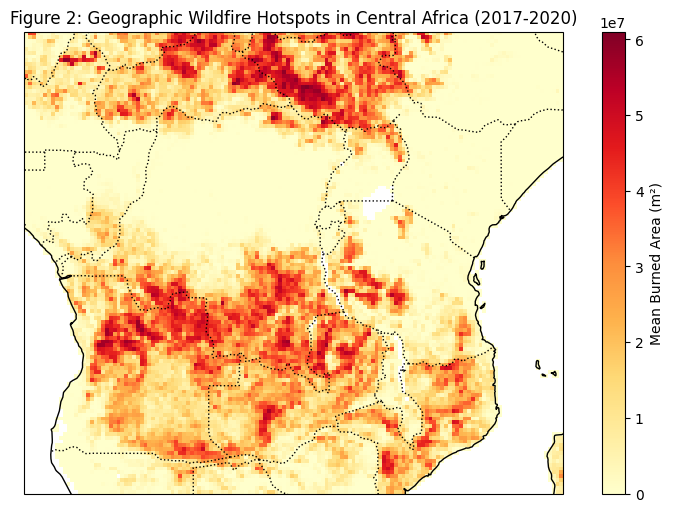

In [2]:
# Calculate the mean burned area over the 4-year training period
mean_fire = train_ds.burned_area.mean(dim='time').compute()

plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')

# Plotting the heatmap
im = mean_fire.plot(ax=ax, transform=ccrs.PlateCarree(), cmap='YlOrRd', 
                    cbar_kwargs={'label': 'Mean Burned Area (m²)'})

plt.title('Figure 2: Geographic Wildfire Hotspots in Central Africa (2017-2020)')
plt.show()

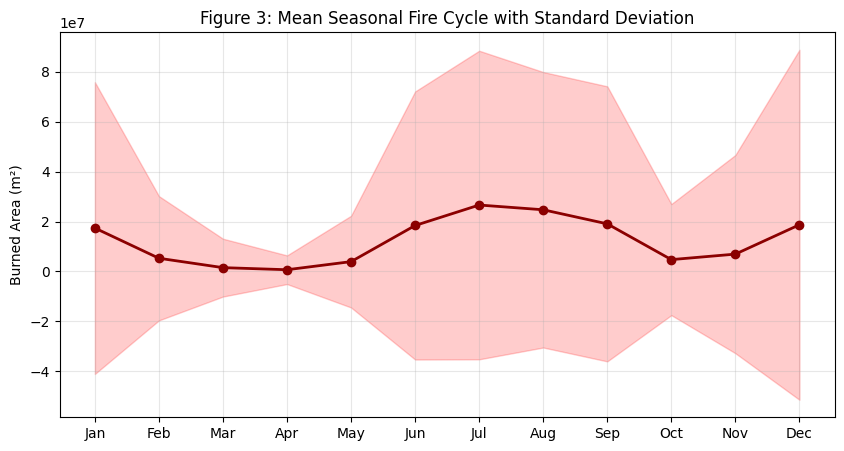

In [3]:
# Group by month and calculate mean/std to show variance
seasonal_cycle = train_ds.burned_area.groupby('time.month').mean(dim=['time', 'lat', 'lon']).compute()
seasonal_std = train_ds.burned_area.groupby('time.month').std(dim=['time', 'lat', 'lon']).compute()

plt.figure(figsize=(10, 5))
plt.fill_between(seasonal_cycle.month, seasonal_cycle - seasonal_std, 
                 seasonal_cycle + seasonal_std, alpha=0.2, color='red')
plt.plot(seasonal_cycle.month, seasonal_cycle, marker='o', color='darkred', linewidth=2)

plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.title('Figure 3: Mean Seasonal Fire Cycle with Standard Deviation')
plt.ylabel('Burned Area (m²)')
plt.grid(alpha=0.3)
plt.show()

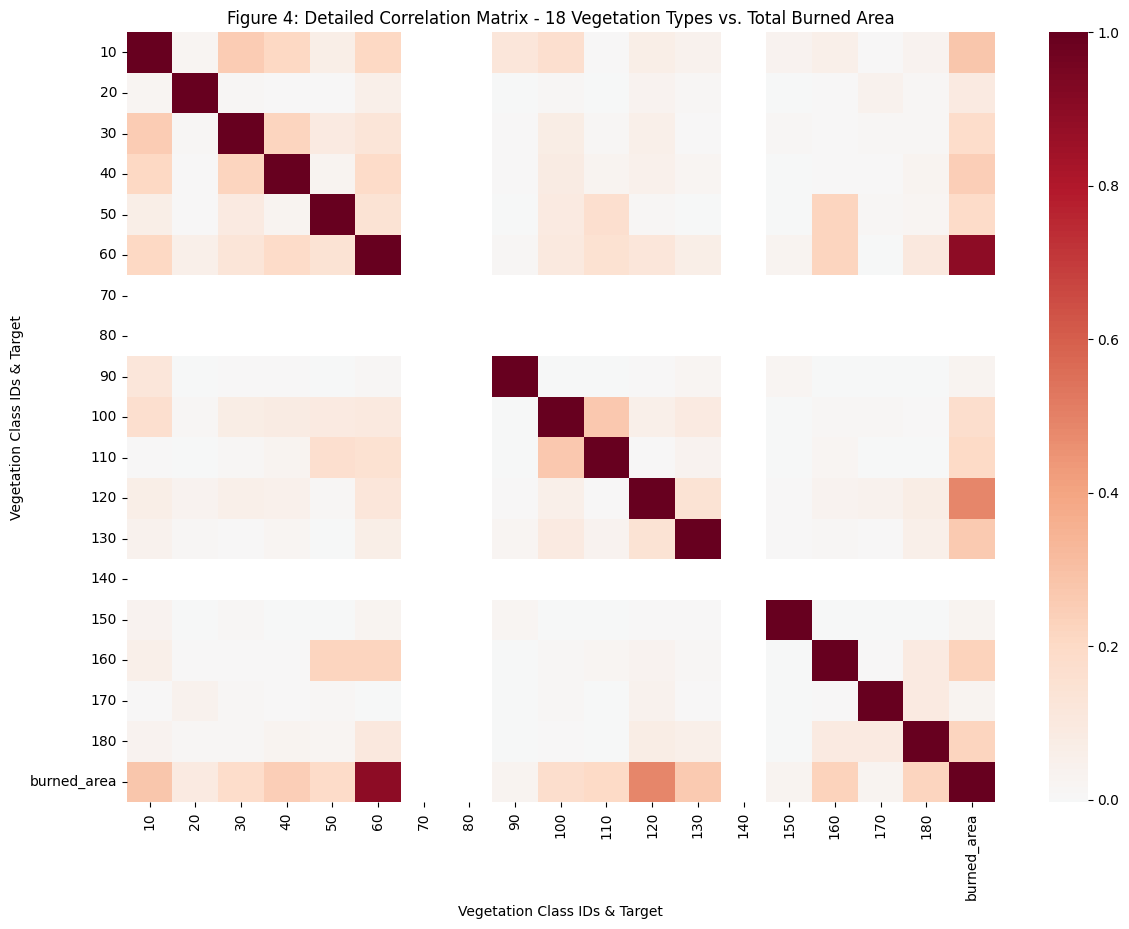

In [7]:
# Select the 18 vegetation fractions and the target
# 1. Extract the 18 classes as individual features
# We select the first 12 months and unstack the vegetation_class dimension
veg_features = train_ds['burned_area_in_vegetation_class'].isel(time=slice(0, 12))

# 2. Convert to dataframe and pivot so each class is a column
# This ensures we get a matrix of 18 features + 1 target
df_veg = veg_features.to_dataframe().reset_index()
df_pivot = df_veg.pivot_table(index=['time', 'lat', 'lon'], 
                              columns='vegetation_class', 
                              values='burned_area_in_vegetation_class')

# 3. Add the target variable
df_target = train_ds['burned_area'].isel(time=slice(0, 12)).to_dataframe()
df_final = pd.concat([df_pivot, df_target], axis=1).dropna().sample(10000)

# 4. Plot with proper labels for non-technical stakeholders
plt.figure(figsize=(14, 10))
corr = df_final.corr()
sns.heatmap(corr, annot=False, cmap='RdBu_r', center=0)
plt.title('Figure 4: Detailed Correlation Matrix - 18 Vegetation Types vs. Total Burned Area')
plt.xlabel('Vegetation Class IDs & Target')
plt.ylabel('Vegetation Class IDs & Target')
plt.show()

In [5]:
# Add this at the end of Notebook 2
print(f"Final EDA Check:")
print(f"Spatial Grid: {train_ds.lat.size} x {train_ds.lon.size}")
print(f"Temporal Steps: {train_ds.time.size} months")
print(f"Feature count: {len(train_ds.data_vars)} variables")

Final EDA Check:
Spatial Grid: 120 x 140
Temporal Steps: 48 months
Feature count: 15 variables
